# Comprehensive AI Model for Farm Yield & Quality Prediction with Decision Support

## 1. Importing Libraries and Loading Data
In this section, we import all the necessary libraries, including:
- **pandas, NumPy, and matplotlib** for data manipulation and visualization.
- **statsmodels (ARIMA)** for time series forecasting.
- **XGBoost** for ensemble regression modeling.
- **Isolation Forest** from scikit-learn for anomaly detection.

We then load the dataset from a CSV file and display an initial preview to verify that the data is loaded correctly.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Time Series Forecasting
from statsmodels.tsa.arima.model import ARIMA

# Ensemble Regression (using XGBoost)
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Anomaly Detection
from sklearn.ensemble import IsolationForest

## 2. Data Preprocessing and Basic Cleaning
This section focuses on cleaning and preparing the data:
- **Conversion to Numeric:** Key columns (e.g., "Area Harvested", "Moisture", "Dry Yield", "Total Fuel", "Fuel Efficiency", "Crude Protein") are converted to numeric values, with proper handling of non-numeric placeholders.
- **Date Handling:** The 'First Harvested' column is converted to a datetime format.
- **Missing Data:** Rows with missing values in critical columns are dropped.
  
This ensures that the dataset is consistent and ready for feature engineering and modeling.


In [28]:
# File paths for both datasets
file_path_2023 = "Kelloe mains Harvest_2023(2).csv"
file_path_2022 = "Kelloe mains Harvest_2022(1).csv"

# Load both datasets
df_2023 = pd.read_csv(file_path_2023)
df_2022 = pd.read_csv(file_path_2022)

# Combine both datasets
df = pd.concat([df_2023, df_2022], ignore_index=True)
print("Initial Merged Data Preview:")
print(df.head())

# Helper function to convert columns to numeric while handling placeholders like '---'
def to_numeric(col):
    return pd.to_numeric(col.replace('---', np.nan), errors='coerce')

# Define numeric columns for modeling
numeric_cols = [
    "Area Harvested", "Moisture", "Dry Yield", "Total Dry Yield",
    "Speed", "Total Fuel", "Fuel Efficiency", "Crude Protein"
]

# Convert numeric columns
for col in numeric_cols:
    if col in df.columns:
        df[col] = to_numeric(df[col])

# Convert 'First Harvested' to datetime format
df['First Harvested'] = pd.to_datetime(df['First Harvested'], format='%b %d, %Y', errors='coerce')

# Drop rows with missing critical data (numeric columns and date)
df_clean = df.dropna(subset=numeric_cols + ['First Harvested']).reset_index(drop=True)
print("\nCleaned Merged Data Shape:", df_clean.shape)

Initial Merged Data Preview:
    Clients         Farms     Fields               Machine Name  \
0  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
1  Mcdonald  kelloe mains     birsby  8400i - SK19 LFR (R Wood)   
2  Mcdonald  kelloe mains     birsby  8400i - SK16 GTY (R Wood)   
3  Mcdonald  kelloe mains     birsby  8500i - SL22 SYY (R Wood)   
4  Mcdonald  kelloe mains  Craig mae  8500i - SL22 SYY (R Wood)   

           Equipment         Operators Varieties  \
0  1Z08500YANU622386  Unknown Operator   1ST Cut   
1  1Z08400YEKU619149  Unknown Operator   2ND CUT   
2  1Z08400YJGR515326  Unknown Operator   3RD CUT   
3  1Z08500YANU622386  Unknown Operator   4TH CUT   
4  1Z08500YANU622386  Unknown Operator   1ST Cut   

                                            Work     Crop Type  \
0  Forage Harvesting Grass Forage - May 17, 2023  Grass Forage   
1  Forage Harvesting Grass Forage - Jun 13, 2023  Grass Forage   
2  Forage Harvesting Grass Forage - Jul 20, 2023  Grass F

## 3. Feature Engineering and Additional Derived Metrics
In this section, we enhance the dataset by creating new features that may improve our models' predictive power. This includes:

- **Date-Based Features:**  
  Extract key time components from the 'First Harvested' date, such as:
  - **Year**
  - **Month**
  - **Day**
  - **DayOfWeek**

- **Additional Derived Metrics:**  
  Create new metrics that provide deeper insights into farm performance:
  - **Yield per Area:**  
    Calculated as Dry Yield divided by Area Harvested, this metric normalizes yield production relative to field size.
  - **Fuel Consumption per Yield:**  
    Calculated as Total Fuel divided by Dry Yield, it indicates the fuel efficiency relative to yield output.
  - **Moisture Adjusted Yield:**  
    Adjusts the Dry Yield by accounting for moisture content using the formula: Dry Yield * (1 + Moisture/100).

These derived features are crucial for further data analytics and will be visualized using histograms and scatter plots to explore their distributions and relationships with the original metrics.


Summary Statistics for Derived Metrics:
       Yield_per_Area  Fuel_per_Yield  Moisture_Adjusted_Yield
count      106.000000      106.000000               106.000000
mean       735.431776       34.044438                 6.281804
std       7566.647801       27.050724                 6.659386
min          0.023951        0.000113                 1.141468
25%          0.106512       14.283107                 2.298281
50%          0.240374       29.365593                 5.064845
75%          0.501297       45.649234                 9.337118
max      77903.900831      142.757674                62.531428


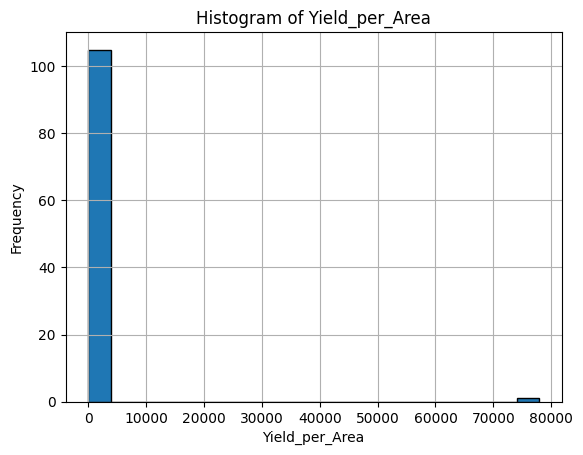

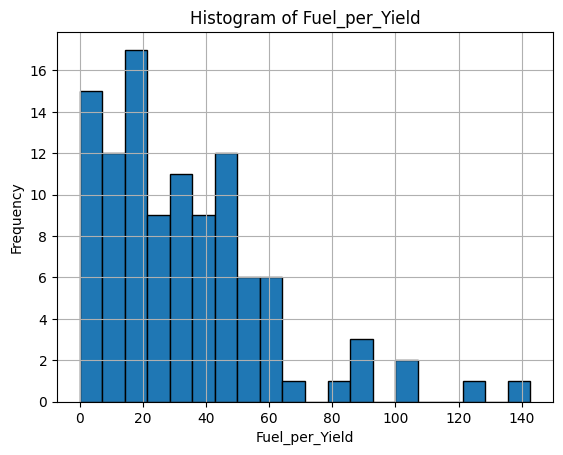

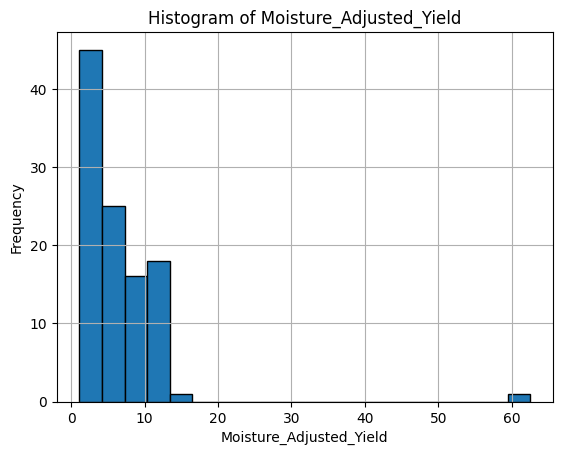

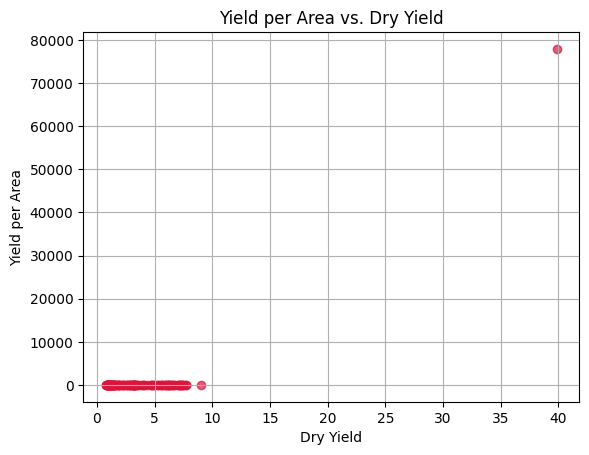

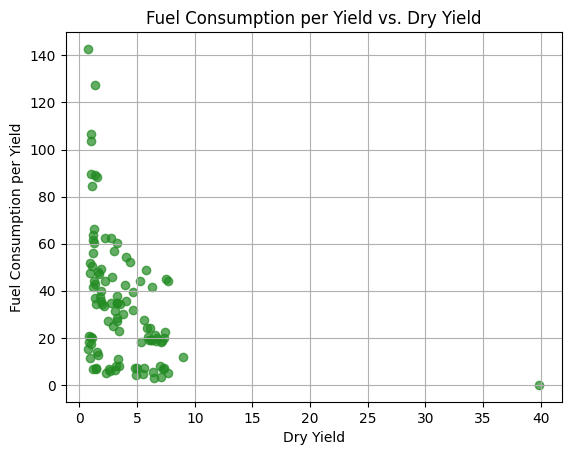

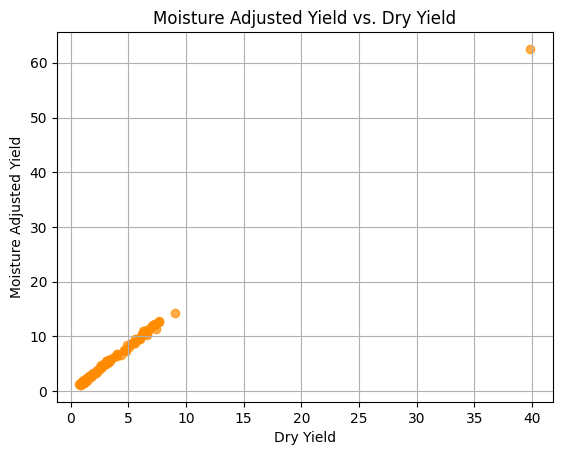

In [29]:
# Create date-based features for improved modeling
df_clean['Year'] = df_clean['First Harvested'].dt.year
df_clean['Month'] = df_clean['First Harvested'].dt.month
df_clean['Day'] = df_clean['First Harvested'].dt.day
df_clean['DayOfWeek'] = df_clean['First Harvested'].dt.dayofweek

# Derived Metric 1: Yield per Area = Dry Yield / Area Harvested
df_clean['Yield_per_Area'] = df_clean['Dry Yield'] / df_clean['Area Harvested']

# Derived Metric 2: Fuel Consumption per Yield = Total Fuel / Dry Yield
df_clean['Fuel_per_Yield'] = df_clean['Total Fuel'] / df_clean['Dry Yield']

# Derived Metric 3: Moisture Adjusted Yield = Dry Yield * (1 + Moisture/100)
df_clean['Moisture_Adjusted_Yield'] = df_clean['Dry Yield'] * (1 + df_clean['Moisture'] / 100)

# Display summary statistics for the derived metrics
print("Summary Statistics for Derived Metrics:")
print(df_clean[['Yield_per_Area', 'Fuel_per_Yield', 'Moisture_Adjusted_Yield']].describe())

# Visualize the Derived Metrics using Histograms
import matplotlib.pyplot as plt

derived_metrics = ['Yield_per_Area', 'Fuel_per_Yield', 'Moisture_Adjusted_Yield']

for metric in derived_metrics:
    plt.figure()
    plt.hist(df_clean[metric].dropna(), bins=20, edgecolor='black')
    plt.title(f'Histogram of {metric}')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

# Visualize Relationships between Derived Metrics and Original Metrics
# Scatter plot: Yield per Area vs. Dry Yield (using a distinct color: crimson)
plt.figure()
plt.scatter(df_clean['Dry Yield'], df_clean['Yield_per_Area'], alpha=0.7, c='crimson')
plt.title("Yield per Area vs. Dry Yield")
plt.xlabel("Dry Yield")
plt.ylabel("Yield per Area")
plt.grid(True)
plt.show()

# Scatter plot: Fuel Consumption per Yield vs. Dry Yield (using a distinct color: forestgreen)
plt.figure()
plt.scatter(df_clean['Dry Yield'], df_clean['Fuel_per_Yield'], alpha=0.7, c='forestgreen')
plt.title("Fuel Consumption per Yield vs. Dry Yield")
plt.xlabel("Dry Yield")
plt.ylabel("Fuel Consumption per Yield")
plt.grid(True)
plt.show()

# Scatter plot: Moisture Adjusted Yield vs. Dry Yield (using a distinct color: darkorange)
plt.figure()
plt.scatter(df_clean['Dry Yield'], df_clean['Moisture_Adjusted_Yield'], alpha=0.7, c='darkorange')
plt.title("Moisture Adjusted Yield vs. Dry Yield")
plt.xlabel("Dry Yield")
plt.ylabel("Moisture Adjusted Yield")
plt.grid(True)
plt.show()


## 4. Time Series Forecasting using ARIMA
In this part of the notebook, we forecast the average daily "Dry Yield":
- **Aggregation:** Compute the daily average "Dry Yield" and set the time series frequency to daily.
- **Splitting Data:** The time series is split into training (e.g., 90%) and testing (10%) sets.
- **Modeling:** An ARIMA model is built and fitted on the training data.
- **Evaluation and Visualization:** The forecast is compared to the actual test data using metrics like Mean Squared Error (MSE), and a plot visualizes the training data, test data, and forecasted values.


23:43:29 - cmdstanpy - INFO - Chain [1] start processing
23:43:29 - cmdstanpy - INFO - Chain [1] done processing
23:43:29 - cmdstanpy - INFO - Chain [1] start processing
23:43:29 - cmdstanpy - INFO - Chain [1] done processing
23:43:29 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
23:43:29 - cmdstanpy - INFO - Chain [1] start processing
23:43:33 - cmdstanpy - INFO - Chain [1] done processing
23:43:33 - cmdstanpy - INFO - Chain [1] start processing
23:43:33 - cmdstanpy - INFO - Chain [1] done processing
23:43:33 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
23:43:33 - cmdstanpy - INFO - Chain [1] start processing
23:43:44 - cmdstanpy - INFO - Chain [1] done processing
23:43:44 - cmdstanpy - INFO - Chain [1] start processing
23:43:44 - cmdstanpy - INFO - Chain [1] done processing
23:43:45 -


Best Config: ('multiplicative', 0.001, 20, 100) MSE: 0.42647570218885533


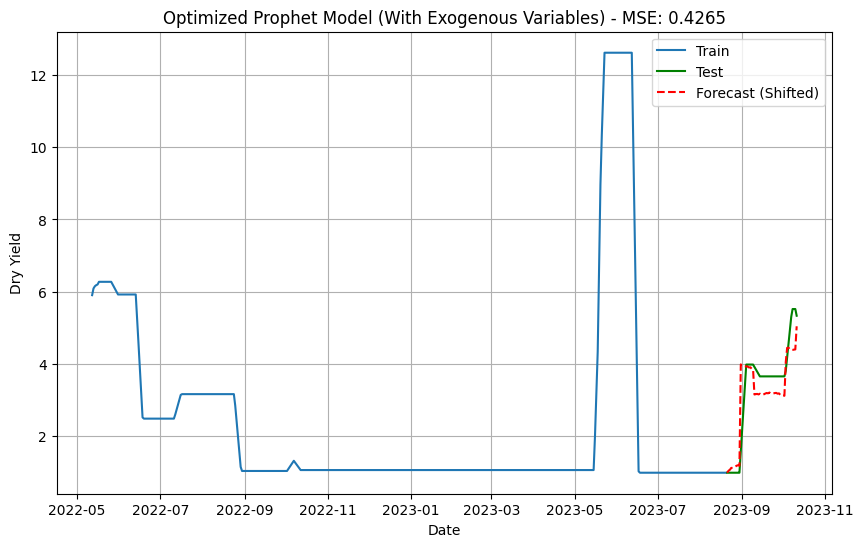

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Ensure 'First Harvested' is a datetime
df_clean['First Harvested'] = pd.to_datetime(df_clean['First Harvested'], errors='coerce')

# Convert necessary columns to numeric
numeric_cols = ["Moisture", "Speed", "Total Fuel", "Fuel Efficiency", "Crude Protein", "Dry Yield"]
for col in numeric_cols:
    if col in df_clean.columns:
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Drop non-numeric columns before aggregating
df_numeric = df_clean[['First Harvested'] + numeric_cols]

# Aggregate and ensure daily continuity
prophet_df = df_numeric.groupby('First Harvested').mean().reset_index()
prophet_df.rename(columns={'First Harvested': 'ds', 'Dry Yield': 'y'}, inplace=True)
prophet_df = prophet_df.set_index('ds').asfreq('D').fillna(method='ffill').reset_index()

# Apply rolling mean smoothing
prophet_df['y'] = prophet_df['y'].rolling(window=5, min_periods=1).mean()

# Train-Test Split
split_index = int(len(prophet_df) * 0.9)
train_df = prophet_df.iloc[:split_index].copy()
test_df = prophet_df.iloc[split_index:].copy()

# Define exogenous variables
exog_features = ["Moisture", "Speed", "Total Fuel", "Fuel Efficiency", "Crude Protein"]
train_exog = train_df[['ds'] + exog_features].fillna(method='ffill')  # Ensure 'ds' is included
test_exog = test_df[['ds'] + exog_features].fillna(method='ffill')

# Hyperparameter tuning with expanded search
param_grid = {
    'changepoint_prior_scale': [0.001, 0.005, 0.01, 0.05],
    'seasonality_prior_scale': [5, 10, 20, 30, 40],
    'n_changepoints': [50, 100, 200],
    'seasonality_mode': ['additive', 'multiplicative']
}

best_mse = float('inf')
best_config = None
best_model = None

# Grid search for best model
for sm in param_grid['seasonality_mode']:
    for cps in param_grid['changepoint_prior_scale']:
        for sps in param_grid['seasonality_prior_scale']:
            for ncp in param_grid['n_changepoints']:
                model = Prophet(
                    yearly_seasonality=True,
                    weekly_seasonality=True,
                    daily_seasonality=False,
                    seasonality_mode=sm,
                    changepoint_prior_scale=cps,
                    seasonality_prior_scale=sps,
                    n_changepoints=ncp
                )

                for feature in exog_features:
                    model.add_regressor(feature)

                model.fit(train_df)

                # Ensure 'ds' exists before merging
                future = test_df[['ds']].copy()
                test_exog['ds'] = test_df['ds']  # Fix KeyError by explicitly setting ds
                future = future.merge(test_exog, on='ds', how='left')

                forecast = model.predict(future)

                last_test_value = train_df['y'].iloc[-1]
                forecast['yhat_shifted'] = forecast['yhat'] + (last_test_value - forecast['yhat'].iloc[0])

                merged = forecast[['ds', 'yhat_shifted']].merge(test_df, on='ds', how='inner')
                if len(merged) == 0:
                    continue
                
                mse = mean_squared_error(merged['y'], merged['yhat_shifted'])
                if mse < best_mse:
                    best_mse = mse
                    best_config = (sm, cps, sps, ncp)
                    best_model = model
                    best_forecast = forecast

print("\nBest Config:", best_config, "MSE:", best_mse)

# Final model plot
if best_model:
    plt.figure(figsize=(10,6))
    plt.plot(train_df['ds'], train_df['y'], label='Train')
    plt.plot(test_df['ds'], test_df['y'], label='Test', color='green')
    plt.plot(best_forecast['ds'], best_forecast['yhat_shifted'], label='Forecast (Shifted)', color='red', linestyle='--')
    plt.title(f"Optimized Prophet Model (With Exogenous Variables) - MSE: {best_mse:.4f}")
    plt.xlabel("Date")
    plt.ylabel("Dry Yield")
    plt.legend()
    plt.grid(True)
    plt.show()


## 5. Ensemble Regression Models for Yield & Quality Prediction using XGBoost
This section develops ensemble regression models to predict both yield and quality:
- **Yield Prediction:** An XGBoost regressor is trained on selected features (including operational and date-based features) to predict "Dry Yield".
- **Quality Prediction:** Another XGBoost regressor is trained to predict "Crude Protein".
- **Evaluation:** Both models are evaluated using performance metrics such as MSE and R-squared, and sample predictions are generated for validation.


In [41]:
# Define feature set for regression models
features = ["Area Harvested", "Moisture", "Speed", "Total Fuel", "Fuel Efficiency", 
            "Year", "Month", "Day", "DayOfWeek"]

# ---- Yield Prediction (Target: "Dry Yield") ----
X_yield = df_clean[features]
y_yield = df_clean["Dry Yield"]

# Split into training and testing sets
X_train_y, X_test_y, y_train_y, y_test_y = train_test_split(X_yield, y_yield, test_size=0.2, random_state=42)

# Initialize and train XGBoost regressor for yield prediction
model_xgb_yield = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model_xgb_yield.fit(X_train_y, y_train_y)

# Predict and evaluate yield prediction
y_pred_yield = model_xgb_yield.predict(X_test_y)
yield_mse = mean_squared_error(y_test_y, y_pred_yield)
yield_r2 = r2_score(y_test_y, y_pred_yield)
print("\nYield Prediction Model Metrics:")
print("MSE:", yield_mse)
print("R-squared:", yield_r2)

# ---- Quality Prediction (Target: "Crude Protein") ----
X_quality = df_clean[features]
y_quality = df_clean["Crude Protein"]

# Split into training and testing sets
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_quality, y_quality, test_size=0.2, random_state=42)

# Initialize and train XGBoost regressor for quality prediction
model_xgb_quality = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
model_xgb_quality.fit(X_train_q, y_train_q)

# Predict and evaluate quality prediction
y_pred_quality = model_xgb_quality.predict(X_test_q)
quality_mse = mean_squared_error(y_test_q, y_pred_quality)
quality_r2 = r2_score(y_test_q, y_pred_quality)
print("\nQuality Prediction Model Metrics:")
print("MSE:", quality_mse)
print("R-squared:", quality_r2)


Yield Prediction Model Metrics:
MSE: 0.3771390852761611
R-squared: 0.9306651243923614

Quality Prediction Model Metrics:
MSE: 1.4075234345880452
R-squared: 0.8127091787653642


## 6. Anomaly Detection using Isolation Forest
We integrate an anomaly detection module to identify unusual observations:
- **Feature Selection:** A subset of key operational features is used.
- **Modeling:** The Isolation Forest algorithm is applied with a specified contamination rate to label observations as normal or anomalous.
- **Analysis and Visualization:** The counts of normal versus anomalous observations are printed, and a scatter plot visualizes anomalies (for example, comparing "Dry Yield" against "Fuel Efficiency").



Anomaly Detection Counts:
anomaly
 1    100
-1      6
Name: count, dtype: int64


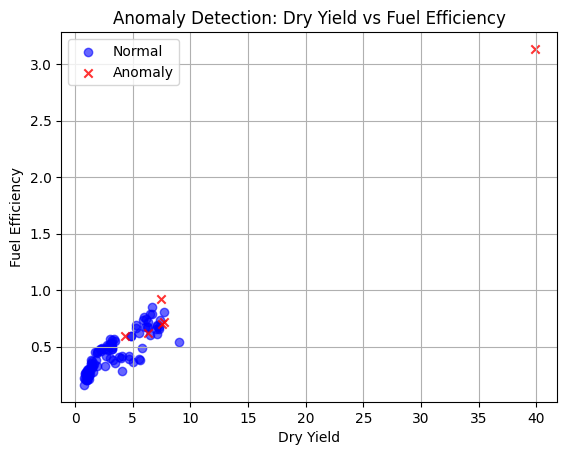

In [42]:
# Select key features for anomaly detection
iso_features = ["Area Harvested", "Moisture", "Dry Yield", "Speed", "Total Fuel", "Fuel Efficiency"]
X_iso = df_clean[iso_features]

# Initialize Isolation Forest (contamination rate can be adjusted based on domain knowledge)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
df_clean['anomaly'] = iso_forest.fit_predict(X_iso)

# Count anomalies vs. normal observations (-1 = anomaly, 1 = normal)
print("\nAnomaly Detection Counts:")
print(df_clean['anomaly'].value_counts())

# (Optional) Visualize anomalies for a pair of features (e.g., Dry Yield vs Fuel Efficiency)
normal_data = df_clean[df_clean['anomaly'] == 1]
anomalies = df_clean[df_clean['anomaly'] == -1]

plt.figure()
plt.scatter(normal_data["Dry Yield"], normal_data["Fuel Efficiency"], alpha=0.6, label='Normal', c='blue')
plt.scatter(anomalies["Dry Yield"], anomalies["Fuel Efficiency"], alpha=0.8, label='Anomaly', c='red', marker='x')
plt.xlabel("Dry Yield")
plt.ylabel("Fuel Efficiency")
plt.title("Anomaly Detection: Dry Yield vs Fuel Efficiency")
plt.legend()
plt.grid(True)
plt.show()

## 7. Decision Support System (DSS)
A rule-based decision support system is implemented to provide actionable insights:
- **KPI Computation:** Calculate overall average KPIs such as "Dry Yield", "Fuel Efficiency", and "Crude Protein".
- **Thresholds:** Define acceptable thresholds for these KPIs based on domain expertise.
- **Recommendations:** Compare the computed KPIs against the thresholds to generate recommendations (e.g., if "Dry Yield" is below the threshold, suggest reviewing field management practices).


In [43]:
# Define KPI thresholds (example values; adjust based on domain expertise)
yield_threshold = 12.0         # Minimum acceptable Dry Yield
fuel_eff_threshold = 8.0       # Minimum acceptable Fuel Efficiency
protein_threshold = 25.0       # Minimum acceptable Crude Protein

# Compute overall average KPIs from the dataset
avg_dry_yield = df_clean["Dry Yield"].mean()
avg_fuel_eff = df_clean["Fuel Efficiency"].mean()
avg_crude_protein = df_clean["Crude Protein"].mean()

print("\nOverall KPIs:")
print("Average Dry Yield:", avg_dry_yield)
print("Average Fuel Efficiency:", avg_fuel_eff)
print("Average Crude Protein:", avg_crude_protein)

# Generate decision support recommendations based on KPI thresholds
recommendations = []
if avg_dry_yield < yield_threshold:
    recommendations.append("Dry Yield is below the expected threshold. Consider reviewing field management and optimizing harvest timing.")
else:
    recommendations.append("Dry Yield is within the expected range.")

if avg_fuel_eff < fuel_eff_threshold:
    recommendations.append("Fuel Efficiency is lower than expected. Evaluate machine maintenance and adjust operational parameters to improve efficiency.")
else:
    recommendations.append("Fuel Efficiency is satisfactory.")

if avg_crude_protein < protein_threshold:
    recommendations.append("Crude Protein levels are below target quality. Revisit fertilization and harvest practices.")
else:
    recommendations.append("Crude Protein levels meet the quality standards.")


Overall KPIs:
Average Dry Yield: 3.835162814216982
Average Fuel Efficiency: 0.4873636074245284
Average Crude Protein: 14.242636843490565


## 8. Integration and Final Output
In this section, we integrate all components into one comprehensive pipeline:
- **Integration Function:** A function aggregates the outputs from the ARIMA forecasting, XGBoost regression models, anomaly detection, and decision support system.
- **Summary Generation:** The function returns a summary containing model evaluations, forecasts, anomaly counts, and decision support recommendations.
- **Final Display:** The integrated results are printed and visualized, providing a complete overview of predictions and actionable insights.


In [44]:
def integrated_prediction_pipeline():
    """
    This function integrates time series forecasting, regression predictions,
    anomaly detection, and decision support to provide comprehensive outputs.
    """
    # Time Series Forecast Summary
    ts_forecast_summary = {
        "ARIMA_Model_Summary": model_fit.summary().as_text(),
        "Test_MSE": ts_mse,
        "Forecast": forecast_ts
    }
    
    # Regression Predictions (Yield and Quality)
    regression_summary = {
        "Yield": {
            "MSE": yield_mse,
            "R2": yield_r2,
            "Model": model_xgb_yield,
            "Sample_Predictions": y_pred_yield[:5]
        },
        "Quality": {
            "MSE": quality_mse,
            "R2": quality_r2,
            "Model": model_xgb_quality,
            "Sample_Predictions": y_pred_quality[:5]
        }
    }
    
    # Anomaly Detection Summary
    anomaly_summary = {
        "Total_Observations": df_clean.shape[0],
        "Normal": int((df_clean['anomaly'] == 1).sum()),
        "Anomalies": int((df_clean['anomaly'] == -1).sum())
    }
    
    # Decision Support Recommendations
    dss_summary = {
        "Average_Dry_Yield": avg_dry_yield,
        "Average_Fuel_Efficiency": avg_fuel_eff,
        "Average_Crude_Protein": avg_crude_protein,
        "Recommendations": recommendations
    }
    
    # Return all summaries
    return {
        "TimeSeriesForecast": ts_forecast_summary,
        "RegressionModels": regression_summary,
        "AnomalyDetection": anomaly_summary,
        "DecisionSupport": dss_summary
    }

# Run the integrated pipeline and capture results
final_results = integrated_prediction_pipeline()

## 9. Visualization of Results
The final part of the notebook provides visualizations to help stakeholders understand the outcomes:
- **Time Series Forecast Plot:** A combined plot shows historical data alongside the ARIMA forecast.
- **Anomaly Visualization:** Graphs highlight detected anomalies in key features.
- **Model Performance Metrics:** Summaries of model performance (e.g., MSE, R-squared) are presented for both yield and quality predictions.

This comprehensive notebook serves as an end-to-end AI solution for predicting future farm outcomes and supporting decision-making with integrated data analytics, forecasting, regression modeling, anomaly detection, and decision support.


--- Integrated Model Results ---

Time Series Forecast Summary:
                                     SARIMAX Results                                     
Dep. Variable:                         Dry Yield   No. Observations:                  134
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                -181.963
Date:                           Fri, 14 Mar 2025   AIC                            373.926
Time:                                   23:48:43   BIC                            387.736
Sample:                               05-16-2023   HQIC                           379.533
                                    - 09-26-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3427     53.676      0.006      0.995   

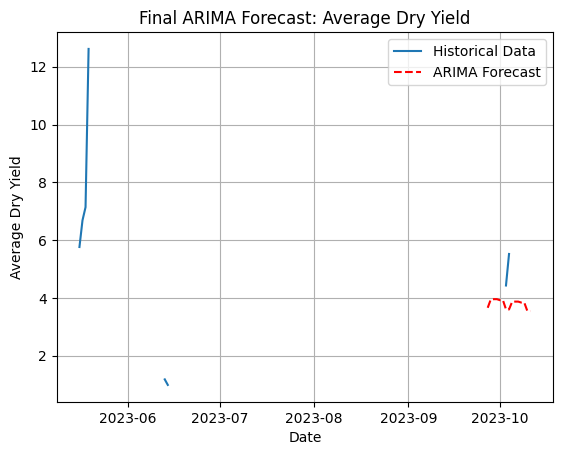

In [45]:
print("\n--- Integrated Model Results ---\n")

print("Time Series Forecast Summary:")
print(final_results["TimeSeriesForecast"]["ARIMA_Model_Summary"])
print("ARIMA Test MSE:", final_results["TimeSeriesForecast"]["Test_MSE"])
print("\nRegression Model Results (Yield Prediction):")
print("MSE:", final_results["RegressionModels"]["Yield"]["MSE"])
print("R-squared:", final_results["RegressionModels"]["Yield"]["R2"])
print("\nRegression Model Results (Quality Prediction):")
print("MSE:", final_results["RegressionModels"]["Quality"]["MSE"])
print("R-squared:", final_results["RegressionModels"]["Quality"]["R2"])
print("\nAnomaly Detection Summary:")
print("Total Observations:", final_results["AnomalyDetection"]["Total_Observations"])
print("Normal Observations:", final_results["AnomalyDetection"]["Normal"])
print("Anomalies Detected:", final_results["AnomalyDetection"]["Anomalies"])
print("\nDecision Support Recommendations:")
for rec in final_results["DecisionSupport"]["Recommendations"]:
    print("- " + rec)

# (Optional) Visualize final time series forecast with future predictions
plt.figure()
plt.plot(ts_yield.index, ts_yield, label='Historical Data')
plt.plot(test_ts.index, forecast_ts, label='ARIMA Forecast', color='red', linestyle='--')
plt.title("Final ARIMA Forecast: Average Dry Yield")
plt.xlabel("Date")
plt.ylabel("Average Dry Yield")
plt.legend()
plt.grid(True)
plt.show()